In [ ]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "rescomp", "rescomp")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "Thinned_Rescomp", "utils")))

from file_io import load_bundle_data
from paper_visualization import (
    configure_paper_style,
    plot_reservoir_response,
    plot_replica_pair,
    plot_replica_convergence,
    plot_reservoir_heatmap,
    plot_lorenz_attractor,
)
import numpy as np

configure_paper_style()

### Compute and Save High VPT Matrices

In [2]:
# Paper Parameters from the Global Forecasts in Reservoir Computers Paper
# n = 50
# network_type = "undirected_erdos"
# rho = 16.81
# p = 0.1
# mean_degree = n * p
# alpha = 2.7e-08
# gamma = 8.78
# sigma = 0.187
# tol = 5.
# duration = 8
# switch = 6

# Good Parameters from our work
# n = 50
# network_type = "directed_erdos"
# rho = 2
# mean_degree = 5
# p = mean_degree / n
# alpha = 2e-08
# gamma = 10
# sigma = 0.014
# tol = 5.0
# duration = 8
# switch = 6

# Bad Parameters from our work
n = 50
network_type = "directed_erdos"
rho = 10
mean_degree = 5
p = mean_degree / n
alpha = 2e-08
gamma = 10
sigma = 0.014
tol = 5.0
duration = 8
switch = 6

In [3]:
# build_and_save_best_reservoir(
#     n,
#     network_type,
#     rho,
#     mean_degree,
#     alpha,
#     gamma,
#     sigma,
#     tol,
#     duration,
#     switch,
#     draw_count=100,
#     vpt_upper_bound=1.0,
#     )

In [4]:
A, initial_conditions, t_train, U_train, t_test, U_test, U_hat_train, U_hat_pred, states_train, states_pred, replica_states_1, replica_states_2, W_out, vpt = load_bundle_data(
    n, network_type, rho, mean_degree, alpha, gamma, sigma, tol, duration, switch
)

vpt = vpt[0]
reservoir_states = np.vstack((states_train, states_pred))
T = states_train.shape[0]
t = np.arange(reservoir_states.shape[0])
u_true = np.vstack((U_train[:-1], U_test))
u_hat = np.vstack((U_hat_train, U_hat_pred))

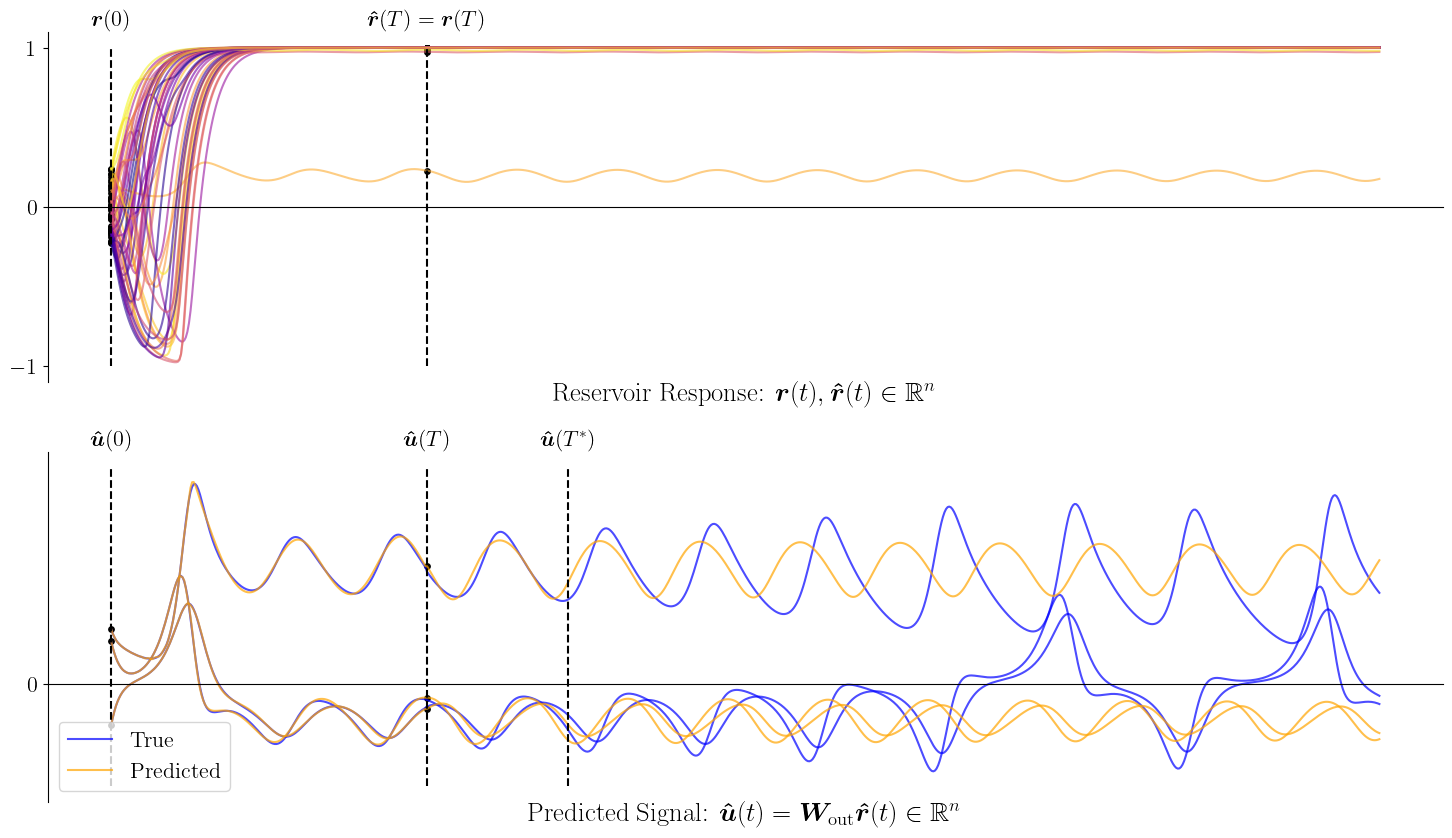

In [5]:
plot_reservoir_response(reservoir_states, u_true, u_hat, T, t, vpt, n)

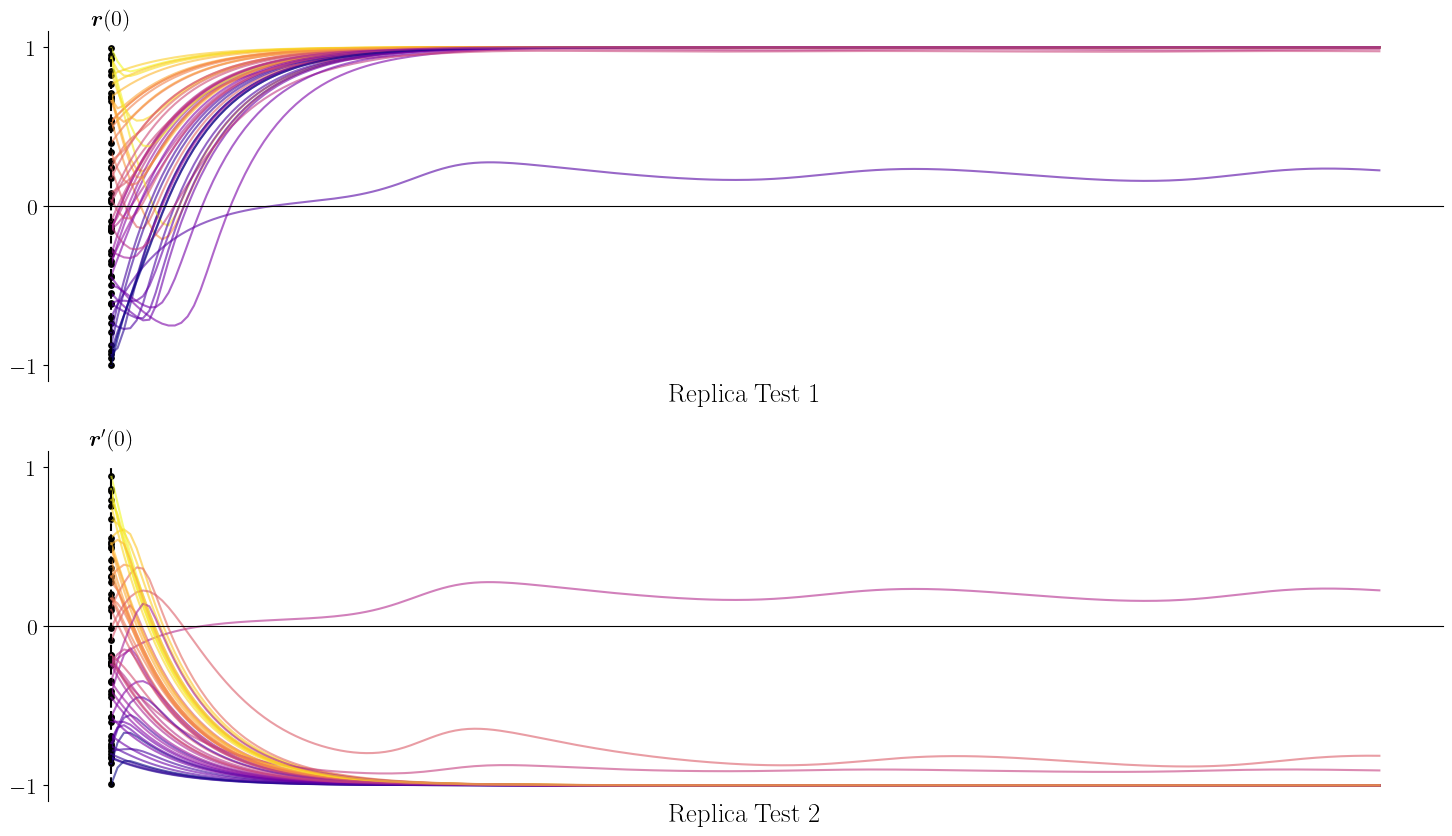

In [6]:
plot_replica_pair(replica_states_1, replica_states_2, t_train, n)

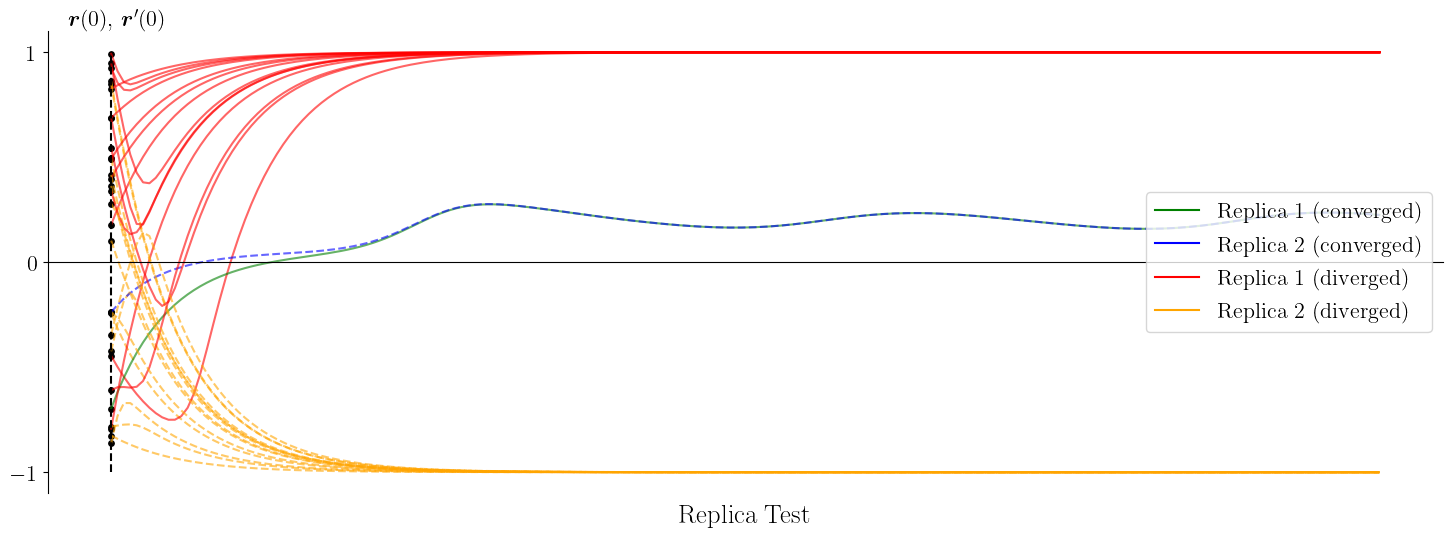

In [12]:
plot_replica_convergence(replica_states_1, replica_states_2, t_train, n, tail=50, conv_tol=1e-3)

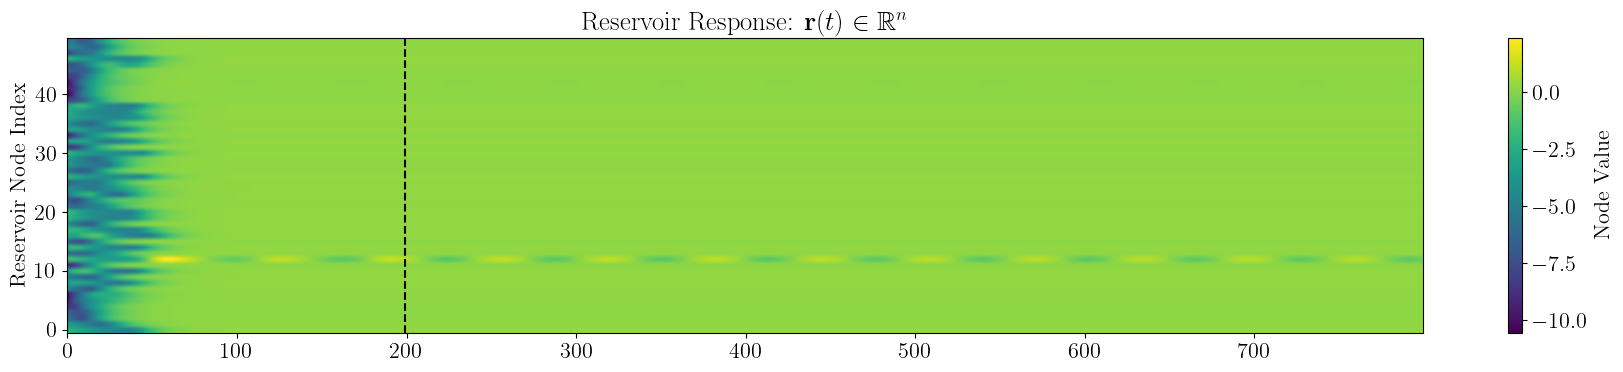

In [8]:
plot_reservoir_heatmap(reservoir_states, u_true, u_hat, T, t)

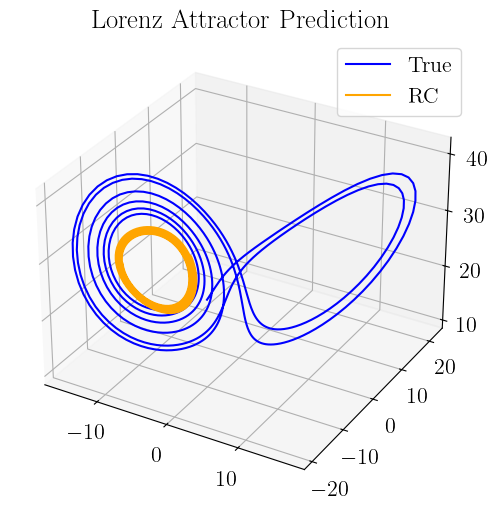

In [ ]:
plot_lorenz_attractor(U_test, U_hat_pred)